# Brazilian E-Commerce 데이터 탐색

## 프로젝트 개요

**목표**: Olist 이커머스 플랫폼의 고객 행동 분석을 위한 데이터 구조 파악 및 EDA

**데이터**: Brazilian E-Commerce Public Dataset (Kaggle)
- 9개 CSV 파일, 약 100,000건 주문, 2016~2018년

**이 노트북의 역할**:
1. 9개 테이블 로드 및 구조 파악
2. 테이블 간 관계 (ERD) 정리
3. 결측치 / 이상치 / 데이터 품질 점검
4. 분석 가능한 핵심 데이터셋 결정

In [13]:
# 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
import warnings

# 옵션 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# 한글 폰트 강제 설정 (Windows)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

# 폰트를 시스템에 등록
fm.fontManager.addfont(font_path)

# matplotlib 전역 설정
mpl.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = font_name

# 시각화 스타일
sns.set_style("whitegrid", {"font.family": font_name})
plt.rcParams['figure.figsize'] = (12, 5)

# 폰트 설정 확인
print(f"적용된 폰트: {font_name}")
print("라이브러리 import 완료")

적용된 폰트: Malgun Gothic
라이브러리 import 완료


In [14]:
# 9개 CSV 파일 로드
DATA_PATH = '../data/'

orders        = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
order_items   = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
order_payments= pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
customers     = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
products      = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
sellers       = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
geolocation   = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

# 각 테이블 크기 출력
tables = {
    'orders': orders, 'order_items': order_items, 'order_payments': order_payments,
    'order_reviews': order_reviews, 'customers': customers, 'products': products,
    'sellers': sellers, 'geolocation': geolocation, 'category_translation': category_translation
}

print("테이블별 크기:")
print("=" * 60)
for name, df in tables.items():
    print(f"{name:25s}: {len(df):>8,}행 × {len(df.columns):>2}컬럼")

테이블별 크기:
orders                   :   99,441행 ×  8컬럼
order_items              :  112,650행 ×  7컬럼
order_payments           :  103,886행 ×  5컬럼
order_reviews            :   99,224행 ×  7컬럼
customers                :   99,441행 ×  5컬럼
products                 :   32,951행 ×  9컬럼
sellers                  :    3,095행 ×  4컬럼
geolocation              : 1,000,163행 ×  5컬럼
category_translation     :       71행 ×  2컬럼


## 1. 테이블 관계 (ERD) 파악

각 테이블이 어떻게 연결되는지 파악해야 분석 가능합니다.

customers ─── orders ─── order_items ─── products
├── order_payments      └── sellers
└── order_reviews

**핵심 키 (Foreign Key)**:
- `customer_id`: orders -> customers
- `order_id`: order_items, payments, reviews -> orders
- `product_id`: order_items -> products
- `seller_id`: order_items -> sellers
- `customer_unique_id` ★: customers 내부에 있음. 같은 고객의 여러 주문 추적용

In [15]:
# orders 테이블 (가장 중심)
print("orders 테이블")
print("=" * 60)
print(orders.head())
print(f"\nShape: {orders.shape}")
print(f"\n컬럼:")
print(orders.dtypes)

orders 테이블
                           order_id                       customer_id order_status order_purchase_timestamp    order_approved_at order_delivered_carrier_date order_delivered_customer_date  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15          2017-10-04 19:55:00           2017-10-10 21:25:13   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27          2018-07-26 14:31:00           2018-08-07 15:27:45   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23          2018-08-08 13:50:00           2018-08-17 18:06:29   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59          2017-11-22 13:39:59           2017-12-02 00:28:42   
4  ad21c59c0840e6cb83a9ceb5573f815

In [16]:
# customers 테이블
print("customers 테이블")
print("=" * 60)
print(customers.head())
print(f"\nShape: {customers.shape}")
print(f"\n customer_id vs customer_unique_id:")
print(f"customer_id 고유값: {customers['customer_id'].nunique():,}")
print(f"customer_unique_id 고유값: {customers['customer_unique_id'].nunique():,}")
print(f"-> 같은 사람이 여러 customer_id를 가짐 (재구매 시 새 ID 부여)")

customers 테이블
                        customer_id                customer_unique_id  customer_zip_code_prefix          customer_city customer_state
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0                     14409                 franca             SP
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3                      9790  sao bernardo do campo             SP
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e                      1151              sao paulo             SP
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c                      8775        mogi das cruzes             SP
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066                     13056               campinas             SP

Shape: (99441, 5)

 customer_id vs customer_unique_id:
customer_id 고유값: 99,441
customer_unique_id 고유값: 96,096
-> 같은 사람이 여러 customer_id를 가짐 (재구매 시 새 ID 부여)


In [17]:
# order_items 테이블 (실제 매출 정보)
print("order_items 테이블")
print("=" * 60)
print(order_items.head())
print(f"\nShape: {order_items.shape}")
print(f"\n 한 주문(order_id)에 여러 상품 가능:")
print(f"고유 주문 수: {order_items['order_id'].nunique():,}")
print(f"주문-상품 행 수: {len(order_items):,}")

order_items 테이블
                           order_id  order_item_id                        product_id                         seller_id  shipping_limit_date   price  freight_value
0  00010242fe8c5a6d1ba2dd792cb16214              1  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202  2017-09-19 09:45:35   58.90          13.29
1  00018f77f2f0320c557190d7a144bdd3              1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36  2017-05-03 11:05:13  239.90          19.93
2  000229ec398224ef6ca0657da4fc703e              1  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d  2018-01-18 14:48:30  199.00          17.87
3  00024acbcdf0a6daa1e931b038114c75              1  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4  2018-08-15 10:10:18   12.99          12.79
4  00042b26cf59d7ce69dfabb4e55b4fd9              1  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87  2017-02-13 13:57:51  199.90          18.14

Shape

고유 주문 수: 98,666
주문-상품 행 수: 112,650


In [18]:
# order_payments 테이블
print("order_payments 테이블")
print("=" * 60)
print(order_payments.head())
print(f"\nShape: {order_payments.shape}")
print(f"\n결제 방식 분포:")
print(order_payments['payment_type'].value_counts())

order_payments 테이블
                           order_id  payment_sequential payment_type  payment_installments  payment_value
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card                     8          99.33
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card                     1          24.39
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card                     1          65.71
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card                     8         107.78
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card                     2         128.45

Shape: (103886, 5)

결제 방식 분포:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [19]:
# 모든 테이블 결측치 점검
print("테이블별 결측치 점검")
print("=" * 60)

for name, df in tables.items():
    null_count = df.isnull().sum().sum()
    if null_count > 0:
        print(f"\n {name}:")
        nulls = df.isnull().sum()
        nulls_pct = (df.isnull().sum() / len(df) * 100).round(2)
        result = pd.DataFrame({'결측수': nulls, '비율(%)': nulls_pct})
        print(result[result['결측수'] > 0])

테이블별 결측치 점검

 orders:


                                결측수  비율(%)
order_approved_at               160   0.16
order_delivered_carrier_date   1783   1.79
order_delivered_customer_date  2965   2.98

 order_reviews:
                          결측수  비율(%)
review_comment_title    87656  88.34
review_comment_message  58247  58.70

 products:
                            결측수  비율(%)
product_category_name       610   1.85
product_name_lenght         610   1.85
product_description_lenght  610   1.85
product_photos_qty          610   1.85
product_weight_g              2   0.01
product_length_cm             2   0.01
product_height_cm             2   0.01
product_width_cm              2   0.01


## 2. 데이터 품질 점검

### 2-1. 결측치 해석

발견된 결측치는 **모두 비즈니스 의미가 있는 결측**:
- `order_approved_at`: 결제 미완료 주문 -> RFM에서 제외 검토
- `order_delivered_*`: 배송 미완료 -> 배송 분석에서 제외, RFM에는 포함
- `review_comment_*`: 리뷰 작성 안 함 -> 정상 (점수만 분석에 사용)
- `product_category_name`: 분류 안 된 상품 -> "기타"로 처리

### 2-2. 다음 점검 항목
- 주문 상태 분포 (취소/배송완료/진행중)
- 가격 이상치
- 시간 이상치 (배송 후 주문 같은 무결성)
- 중복 데이터

In [20]:
# 주문 상태별 분포
print("주문 상태 분포")
print("=" * 50)
status_counts = orders['order_status'].value_counts()
status_pct = (status_counts / len(orders) * 100).round(2)

result = pd.DataFrame({
    '건수': status_counts,
    '비율(%)': status_pct
})
print(result)

print(f"\n 분석 시 고려사항:")
print(f"- delivered 외 상태는 RFM 분석에서 제외 검토")
print(f"- canceled, unavailable는 매출 계산 시 제외 필수")

주문 상태 분포
                 건수  비율(%)
order_status              
delivered     96478  97.02
shipped        1107   1.11
canceled        625   0.63
unavailable     609   0.61
invoiced        314   0.32
processing      301   0.30
created           5   0.01
approved          2   0.00

 분석 시 고려사항:
- delivered 외 상태는 RFM 분석에서 제외 검토
- canceled, unavailable는 매출 계산 시 제외 필수


가격 (price) 이상치 탐지
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

 IQR 기준 이상치: 8,427건 (7.48%)
상한: R$277.40


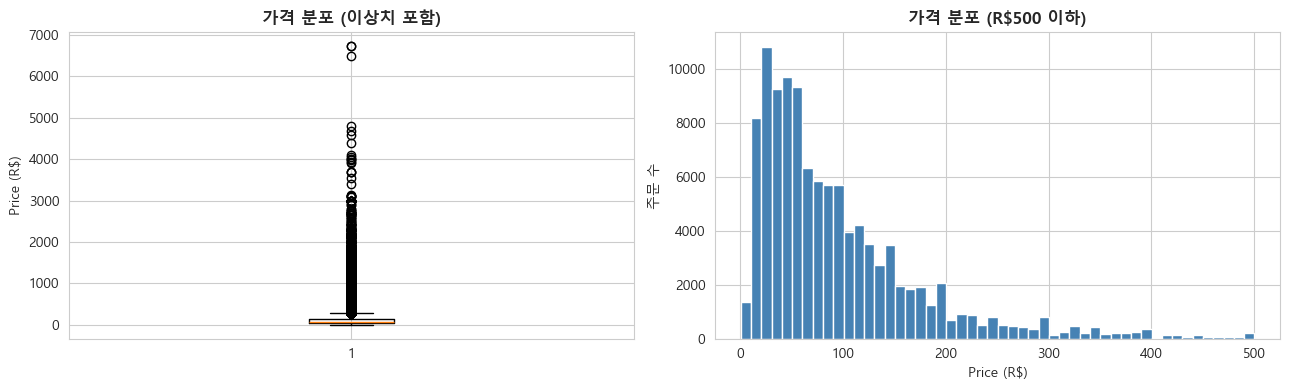

In [21]:
# order_items의 가격 분포 (이상치)
print("가격 (price) 이상치 탐지")
print("=" * 50)
print(order_items['price'].describe())

# IQR 기반 이상치
q1 = order_items['price'].quantile(0.25)
q3 = order_items['price'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

outliers = order_items[(order_items['price'] > upper) | (order_items['price'] < lower)]
print(f"\n IQR 기준 이상치: {len(outliers):,}건 ({len(outliers)/len(order_items)*100:.2f}%)")
print(f"상한: R${upper:.2f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot(order_items['price'])
axes[0].set_title('가격 분포 (이상치 포함)', fontweight='bold')
axes[0].set_ylabel('Price (R$)')

# 1000원 이하만 (대부분의 데이터)
axes[1].hist(order_items[order_items['price'] <= 500]['price'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('가격 분포 (R$500 이하)', fontweight='bold')
axes[1].set_xlabel('Price (R$)')
axes[1].set_ylabel('주문 수')

plt.tight_layout()
plt.show()

In [22]:
# 시간 컬럼을 datetime으로 변환
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print("시간 무결성 검증")
print("=" * 50)

# 1) 주문일 < 승인일 (당연한 순서)
issue1 = orders[orders['order_approved_at'] < orders['order_purchase_timestamp']]
print(f"주문일 > 승인일 (시간 역전): {len(issue1)}건")

# 2) 데이터 기간
print(f"\n 데이터 기간:")
print(f"최초 주문: {orders['order_purchase_timestamp'].min()}")
print(f"최근 주문: {orders['order_purchase_timestamp'].max()}")
print(f"분석 기간: {(orders['order_purchase_timestamp'].max() - orders['order_purchase_timestamp'].min()).days}일")

시간 무결성 검증
주문일 > 승인일 (시간 역전): 0건

 데이터 기간:
최초 주문: 2016-09-04 21:15:19
최근 주문: 2018-10-17 17:30:18
분석 기간: 772일


In [23]:
# RFM/코호트 분석을 위한 통합 데이터셋 생성

# 1) 배송 완료된 주문만 필터링 (취소 등 제외)
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f"배송완료 주문: {len(orders_delivered):,}건 (전체의 {len(orders_delivered)/len(orders)*100:.1f}%)")

# 2) order_items를 주문 단위로 집계 (한 주문에 여러 상품 -> 합계)
items_summary = order_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    item_count=('order_item_id', 'count')
).reset_index()

# 3) orders + customers 조인 (customer_unique_id 가져오기 위해)
df = orders_delivered.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state']], 
    on='customer_id'
)

# 4) items_summary 조인 (매출 정보)
df = df.merge(items_summary, on='order_id', how='left')

# 5) 결측 row 제거 (혹시 join 안 된 거)
df = df.dropna(subset=['total_price'])

# 핵심 컬럼만 선택
df = df[['order_id', 'customer_unique_id', 'order_purchase_timestamp', 
         'total_price', 'item_count', 'customer_state']]

print(f"\n 분석용 데이터셋 생성 완료")
print(f"행 수: {len(df):,}")
print(f"고유 고객 수: {df['customer_unique_id'].nunique():,}")
print(f"\n샘플:")
print(df.head())

배송완료 주문: 96,478건 (전체의 97.0%)

 분석용 데이터셋 생성 완료
행 수: 96,478
고유 고객 수: 93,358

샘플:
                           order_id                customer_unique_id order_purchase_timestamp  total_price  item_count customer_state
0  e481f51cbdc54678b7cc49136f2d6af7  7c396fd4830fd04220f754e42b4e5bff      2017-10-02 10:56:33        29.99           1             SP
1  53cdb2fc8bc7dce0b6741e2150273451  af07308b275d755c9edb36a90c618231      2018-07-24 20:41:37       118.70           1             BA
2  47770eb9100c2d0c44946d9cf07ec65d  3a653a41f6f9fc3d2a113cf8398680e8      2018-08-08 08:38:49       159.90           1             GO
3  949d5b44dbf5de918fe9c16f97b45f8a  7c142cf63193a1473d2e66489a9ae977      2017-11-18 19:28:06        45.00           1             RN
4  ad21c59c0840e6cb83a9ceb5573f8159  72632f0f9dd73dfee390c9b22eb56dd6      2018-02-13 21:18:39        19.90           1             SP


In [24]:
# 분석용 데이터셋 저장
df.to_csv('../data/analysis_dataset.csv', index=False)
print(f"저장 완료: {len(df):,}행")

저장 완료: 96,478행


## 3. 탐색 결과 요약

### 데이터 개요
- 분석 기간: 2016~2018년 (약 2년)
- 배송완료 주문: 약 96,000건
- 고유 고객 수: 약 93,000명

### 데이터 품질
- 결측치는 모두 비즈니스 의미가 있는 결측 (배송 중, 미작성 리뷰 등)
- 가격 분포 우편향: 일부 고가 상품 존재
- 시간 무결성 OK (역전 없음)
- 분석 가능한 충분한 규모와 품질 확보